# TIme series parameter estimation example

This worksheet shows an example where we try and predict the number of passangers for a given date

Data is available here: <https://drive.google.com/file/d/1CkL0_PEZwMFHz97sExRBluh_CYxwKqFr/view?usp=sharing>

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import pandas as pd

## Reading in the data and defining the training splits

We have decided on a 67:33 train/test split on our data

In [10]:
df = pd.read_csv('/home/vgv/Downloads/AirPassengers.csv')
timeseries = df[["Passengers"]].values.astype('float32')
 
# train-test split for time series
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

## Create a dataloader

Here we create a dataloader to pass the data to the model

In [11]:
def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset
    
    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+1:i+lookback+1]
        X.append(feature)
        y.append(target)
    return torch.tensor(X), torch.tensor(y)
 
lookback = 4
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)

## Defining the model

Here we have defined the model using an LSTM

In [12]:
class AirModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.linear(x)
        return x
 
model = AirModel()
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=8)

## Training loop

Here we are just looping through the training data and having the model train from it. There is a second loop for validation.

In [13]:
n_epochs = 2000
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # Validation
    if epoch % 100 != 0:
        continue
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred, y_test))
    print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

/tmp/ipykernel_9300/2587186981.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  train_rmse = np.sqrt(loss_fn(y_pred, y_train))
/tmp/ipykernel_9300/2587186981.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  test_rmse = np.sqrt(loss_fn(y_pred, y_test))


Epoch 0: train RMSE 226.3329, test RMSE 425.5829
Epoch 100: train RMSE 181.3645, test RMSE 378.4815
Epoch 200: train RMSE 145.9296, test RMSE 339.9595
Epoch 300: train RMSE 116.7395, test RMSE 305.9328
Epoch 400: train RMSE 94.2204, test RMSE 275.9091
Epoch 500: train RMSE 71.5168, test RMSE 242.4788
Epoch 600: train RMSE 56.1408, test RMSE 214.4126
Epoch 700: train RMSE 44.7762, test RMSE 189.8922
Epoch 800: train RMSE 37.1079, test RMSE 168.8638
Epoch 900: train RMSE 31.6335, test RMSE 150.5650
Epoch 1000: train RMSE 27.8792, test RMSE 134.7388
Epoch 1100: train RMSE 25.3687, test RMSE 121.8478
Epoch 1200: train RMSE 23.5783, test RMSE 111.4742
Epoch 1300: train RMSE 22.4700, test RMSE 103.1684
Epoch 1400: train RMSE 22.3746, test RMSE 97.0480
Epoch 1500: train RMSE 21.0570, test RMSE 92.1511
Epoch 1600: train RMSE 20.8912, test RMSE 88.2387
Epoch 1700: train RMSE 20.1185, test RMSE 85.2325
Epoch 1800: train RMSE 20.2708, test RMSE 83.9933
Epoch 1900: train RMSE 19.6455, test RMSE 81

## Extracting loop

In [14]:
with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_train)
    y_pred = y_pred[:, -1, :]
    train_plot[lookback:train_size] = model(X_train)[:, -1, :]
    # shift test predictions for plotting
    test_plot = np.ones_like(timeseries) * np.nan
    test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1, :]


## Lets do a plot

red is the data used for training and green is what was predicted by the model.

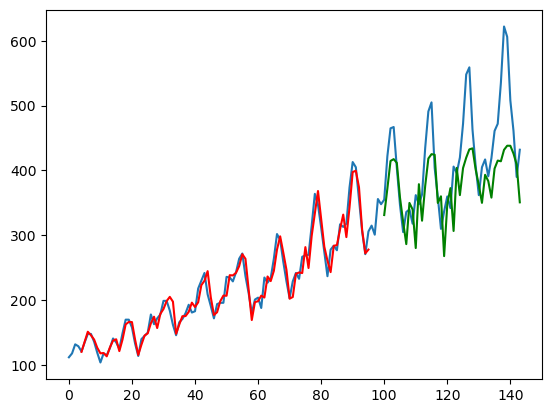

In [15]:
# plot
plt.plot(timeseries)
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()